In [3]:
import seaborn as sns
import pandas as pd 

df = sns.load_dataset("exercise")
df.head()

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


In [22]:
running_df = df[df["kind"] == "running"].copy()
df["time"].unique()

['1 min', '15 min', '30 min']
Categories (3, object): ['1 min', '15 min', '30 min']

In [23]:
    running_df["time_numeric"] = running_df["time"].map({"1 min" : 1, "15 min" : 15, "30 min" : 30})
    running_df["time_numeric"] = running_df["time_numeric"].astype(int)

In [24]:
import statsmodels.formula.api as smf 
model = smf.ols('pulse ~ time_numeric', data = running_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  pulse   R-squared:                       0.492
Model:                            OLS   Adj. R-squared:                  0.474
Method:                 Least Squares   F-statistic:                     27.08
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           1.59e-05
Time:                        01:24:38   Log-Likelihood:                -117.98
No. Observations:                  30   AIC:                             240.0
Df Residuals:                      28   BIC:                             242.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       97.3372      3.819     25.487   

In [25]:
running_df["time_numeric"].dtype

dtype('int64')

In [26]:
df["kind"].unique()

['rest', 'walking', 'running']
Categories (3, object): ['rest', 'walking', 'running']

In [27]:
df.head()

,Unnamed: 0,id,diet,pulse,time,kind,time_numeric
0,0,1,low fat,85,1 min,rest,1
1,1,1,low fat,85,15 min,rest,15
2,2,1,low fat,88,30 min,rest,30
3,3,2,low fat,90,1 min,rest,1
4,4,2,low fat,92,15 min,rest,15


In [28]:
running_df.shape

(30, 7)

In [29]:
model = smf.ols('pulse ~ time_numeric + C(diet)', data = running_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  pulse   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.683
Method:                 Least Squares   F-statistic:                     32.25
Date:                Tue, 02 Jun 2026   Prob (F-statistic):           6.99e-08
Time:                        01:27:08   Log-Likelihood:                -109.82
No. Observations:                  30   AIC:                             225.6
Df Residuals:                      27   BIC:                             229.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            105.3372      3

In [31]:
from scipy import stats

walking_df = df[df["kind"] == "walking"]

r, p = stats.pearsonr(walking_df["pulse"], walking_df["time_numeric"])
print(f"r = {r}, p = {p}")

r = 0.16850832185766013, p = 0.3733964629143093


In [32]:
%whos

Variable               Type                        Data/Info
------------------------------------------------------------
dataframe_columns      function                    <function dataframe_colum<...>ns at 0x0000021BC6E11080>
dataframe_hash         function                    <function dataframe_hash at 0x0000021BC7ED1C60>
df                     DataFrame                   Shape: (90, 7)
dtypes_str             function                    <function dtypes_str at 0x0000021BC6E10EA0>
get_dataframes         function                    <function get_dataframes at 0x0000021BC539D580>
getpass                module                      <module 'getpass' from 'C<...>conda3\\Lib\\getpass.py'>
hashlib                module                      <module 'hashlib' from 'C<...>conda3\\Lib\\hashlib.py'>
import_pandas_safely   function                    <function import_pandas_s<...>ly at 0x0000021BC8017600>
is_data_frame          function                    <function is_data_frame at 0x0000021BC80

In [33]:
lowfatrunning = running_df[running_df["diet"] == "low fat"]["pulse"]
nofatrunning = running_df[running_df["diet"] == "no fat"]["pulse"]

In [37]:
from scipy import stats
t, p = stats.ttest_ind(nofatrunning, lowfatrunning)
print(f"t = {t}, p={p}")

t = 2.7548276980727855, p=0.010204045775895718


In [35]:
!pip install pingouin 

In [39]:
import pingouin as pg 
d = pg.compute_effsize(nofatrunning, lowfatrunning, eftype='cohen')
print(d)

1.005920848182997


In [49]:
len(lowfatrunning)

15

In [51]:
len(nofatrunning)

15

In [53]:
%whos

Variable               Type                        Data/Info
------------------------------------------------------------
d                      float64                     1.005920848182997
dataframe_columns      function                    <function dataframe_colum<...>ns at 0x0000021BC86A0680>
dataframe_hash         function                    <function dataframe_hash at 0x0000021BC539D580>
df                     DataFrame                   Shape: (90, 7)
dtypes_str             function                    <function dtypes_str at 0x0000021BC851FD80>
get_dataframes         function                    <function get_dataframes at 0x0000021BC8015C60>
getpass                module                      <module 'getpass' from 'C<...>conda3\\Lib\\getpass.py'>
hashlib                module                      <module 'hashlib' from 'C<...>conda3\\Lib\\hashlib.py'>
import_pandas_safely   function                    <function import_pandas_s<...>ly at 0x0000021BC86A0540>
is_data_frame         

In [55]:
df.head()

,Unnamed: 0,id,diet,pulse,time,kind,time_numeric
0,0,1,low fat,85,1 min,rest,1
1,1,1,low fat,85,15 min,rest,15
2,2,1,low fat,88,30 min,rest,30
3,3,2,low fat,90,1 min,rest,1
4,4,2,low fat,92,15 min,rest,15


In [57]:
rest_pulse = df[df["kind"] == "rest"]["pulse"]
walking_pulse = df[df["kind"] == "walking"]["pulse"]
running_pulse = df[df["kind"] == "running"]["pulse"]

from scipy import stats
f, p = stats.f_oneway(rest_pulse, walking_pulse, running_pulse)
print(f"f = {f}, p = {p}")

f = 31.987037991079976, p = 3.862192785919453e-11


In [59]:
import pingouin as pg
aov = pg.anova(data=df, dv='pulse', between='kind', detailed=True)
print(aov)

   Source            SS  DF           MS          F         p_unc       np2
0    kind   8326.066667   2  4163.033333  31.987038  3.862193e-11  0.423742
1  Within  11322.833333  87   130.147510        NaN           NaN       NaN


In [63]:
import seaborn as sns
df_fmri = sns.load_dataset("fmri")
df_fmri.head(10)

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970
5,s9,18,stim,parietal,-0.103513
6,s8,18,stim,parietal,-0.064408
7,s7,18,stim,parietal,-0.060526
8,s6,18,stim,parietal,-0.007029
9,s5,18,stim,parietal,-0.040557


In [65]:
df_fmri["subject"].unique()

array(['s13', 's5', 's12', 's11', 's10', 's9', 's8', 's7', 's6', 's4',
       's3', 's2', 's1', 's0'], dtype=object)

In [67]:
df_fmri["event"].unique()

array(['stim', 'cue'], dtype=object)

In [69]:
df_fmri["region"].unique()

array(['parietal', 'frontal'], dtype=object)

In [71]:
df_fmri["timepoint"].unique()

array([18, 14, 17,  9, 16, 15,  0, 13, 12, 11, 10,  3,  7,  8,  2,  6,  5,
        4,  1])

In [73]:
df_fmri[df_fmri["subject"] == "s1"]

,subject,timepoint,event,region,signal
13,s1,18,stim,parietal,-0.046659
27,s1,17,stim,parietal,-0.038021
41,s1,16,stim,parietal,-0.061356
55,s1,15,stim,parietal,-0.110742
69,s1,14,stim,parietal,-0.169312
...,...,...,...,...,...
993,s1,2,cue,frontal,-0.027066
1014,s1,10,cue,frontal,-0.097984
1028,s1,9,cue,frontal,-0.146048
1038,s1,13,cue,frontal,0.028379


In [75]:
stim_signal = df_fmri[df_fmri["event"] == "stim"]["signal"]
cue_signal = df_fmri[df_fmri["event"] == "cue"]["signal"]

from scipy import stats 
t, p = stats.ttest_ind(stim_signal, cue_signal)
print(f"t = {t}, p = {p}")

t = 3.5646274343425075, p = 0.0003805781811075376


In [78]:
import pingouin as pg 
d = pg.compute_effsize(stim_signal, cue_signal, eftype='cohen')
print(d)

0.2185613310602753


In [80]:
len(stim_signal)

532

In [82]:
len(cue_signal)

532

In [86]:
stim_signal.mean()

np.float64(0.013748411381632498)

In [88]:
cue_signal.mean()

np.float64(-0.00666887425343856)

In [90]:
frontal_signal = df_fmri[df_fmri["region"] == "frontal"]["signal"]
parietal_signal = df_fmri[df_fmri["region"] == "parietal"]["signal"]

t, p = stats.ttest_ind(frontal_signal, parietal_signal)
print(f"t = {t}, p = {p}")

t = -0.7783271025229703, p = 0.4365495728493708


In [93]:
d = pg.compute_effsize(frontal_signal, parietal_signal, eftype='cohen')
print(d)

-0.047722296554418134


In [95]:
len(frontal_signal)

532

In [97]:
len(parietal_signal)

532

Text(0.5, 1.0, 'Signal by Brain Region')

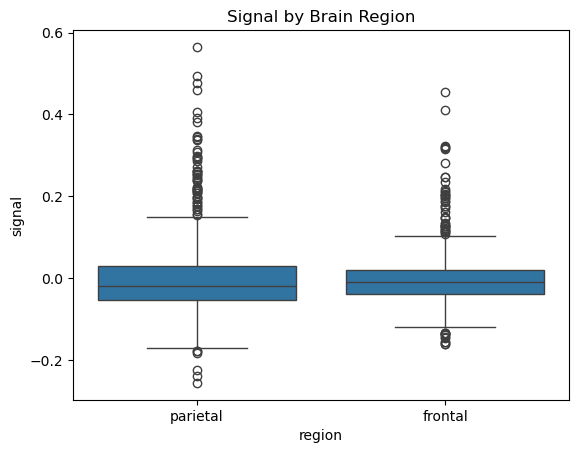

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data = df_fmri, x = "region", y = "signal")
plt.title("Signal by Brain Region")

In [107]:
import statsmodels.formula.api as smf 

In [109]:
df_fmri["timepoint"].dtype

dtype('int64')

In [111]:
model = smf.ols('signal ~ timepoint', data = df_fmri).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 signal   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     88.21
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           3.47e-20
Time:                        16:20:04   Log-Likelihood:                 1049.8
No. Observations:                1064   AIC:                            -2096.
Df Residuals:                    1062   BIC:                            -2086.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0463      0.005      8.688      0.0

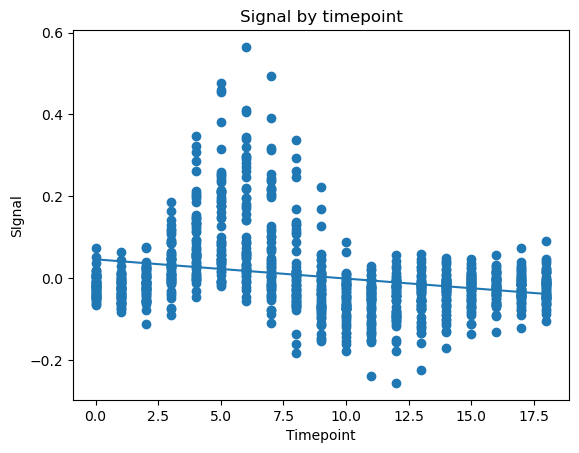

In [113]:
plt.scatter(df_fmri["timepoint"], df_fmri["signal"])
plt.plot([0,18], [0.0463, -0.0383])
plt.title("Signal by timepoint")
plt.xlabel("Timepoint")
plt.ylabel("SIgnal")
plt.show()


In [117]:
model = smf.ols('signal ~ timepoint + I(timepoint**2)', data = df_fmri).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 signal   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     53.11
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.04e-22
Time:                        16:48:12   Log-Likelihood:                 1058.1
No. Observations:                1064   AIC:                            -2110.
Df Residuals:                    1061   BIC:                            -2095.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.0248      0.00

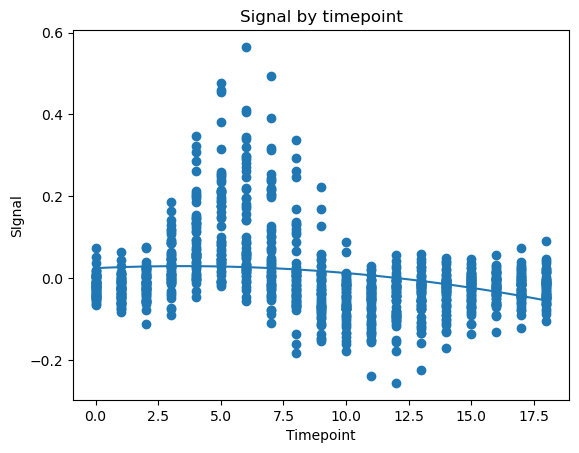

In [121]:
import numpy as np
x = np.linspace(0, 18, 100)
y_pred = 0.0248 + 0.0028*x + (-0.0004)*x**2

plt.scatter(df_fmri["timepoint"], df_fmri["signal"])
plt.plot(x, y_pred)
plt.title("Signal by timepoint")
plt.xlabel("Timepoint")
plt.ylabel("SIgnal")
plt.show()

In [125]:
model = smf.ols('signal ~ timepoint + C(event) + C(region)', data = df_fmri).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 signal   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     34.56
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.61e-21
Time:                        17:05:13   Log-Likelihood:                 1057.0
No. Observations:                1064   AIC:                            -2106.
Df Residuals:                    1060   BIC:                            -2086.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.03

In [126]:
model = smf.ols('signal ~ timepoint + C(event) + C(region) + C(subject)', data = df_fmri).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 signal   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     6.553
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           2.68e-14
Time:                        17:05:25   Log-Likelihood:                 1058.1
No. Observations:                1064   AIC:                            -2082.
Df Residuals:                    1047   BIC:                            -1998.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.03